<a href="https://colab.research.google.com/github/Gerardocmdz/Verano_IA_2026/blob/main/AF4_Supervised_learning_model_Decision_tree/AF4_Supervised_learning_model_Decision_tree.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

AF4_Supervised learning model_Decision tree.

*Members* of the team:

**Gerardo Alberto Córdova Méndez**

ID: **2099413**

**Alejandro Francisco Flores Teillery**

ID: **2101406**

**Octavio Rodriguez Cazarez**

ID: **2100243**

**Cristian Alexis De La Cruz Cabrera**

ID: **2065212**

Class Schedule:V4

# Entrenamiento ML tumores malignos o benignos

### 1. **Primero importaremos las librerias para realizar la actividad**




In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn import tree


### **2. Cargamos la base de datos que utilizaremos con la libreria de pandas en este caso seran sobre tumores mamarios**



In [ ]:
url = "https://raw.githubusercontent.com/Aflorestey-06/CSV_Files/refs/heads/main/data.csv"
df = pd.read_csv(url)
df.head(10)

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN
5,843786,M,12.45,15.70,82.57,477.1,0.12780,0.17000,0.15780,0.08089,...,23.75,103.40,741.6,0.1791,0.5249,0.5355,0.1741,0.3985,0.12440,NaN
6,844359,M,18.25,19.98,119.60,1040.0,0.09463,0.10900,0.11270,0.07400,...,27.66,153.20,1606.0,0.1442,0.2576,0.3784,0.1932,0.3063,0.08368,NaN
7,84458202,M,13.71,20.83,90.20,577.9,0.11890,0.16450,0.09366,0.05985,...,28.14,110.60,897.0,0.1654,0.3682,0.2678,0.1556,0.3196,0.11510,NaN
8,844981,M,13.00,21.82,87.50,519.8,0.12730,0.19320,0.18590,0.09353,...,30.73,106.20,739.3,0.1703,0.5401,0.5390,0.2060,0.4378,0.10720,NaN
9,84501001,M,12.46,24.04,83.97,475.9,0.11860,0.23960,0.22730,0.08543,...,40.68,97.65,711.4,0.1853,1.0580,1.1050,0.2210,0.4366,0.20750,NaN


### **3. Preprocesamieneto de los datos**

**Verificamos si existen valores nulos y checamos las dimensiones**

In [ ]:
nulo = (df.isnull()).sum()
dim = df.shape
print(f"Dimensiones del Data Frame:{dim}\nValores Nulos:\n{nulo}")

Dimensiones del Data Frame:(569, 33)
Valores Nulos:
id                           0
diagnosis                    0
radius_mean                  0
texture_mean                 0
perimeter_mean               0
area_mean                    0
smoothness_mean              0
compactness_mean             0
concavity_mean               0
concave points_mean          0
symmetry_mean                0
fractal_dimension_mean       0
radius_se                    0
texture_se                   0
perimeter_se                 0
area_se                      0
smoothness_se                0
compactness_se               0
concavity_se                 0
concave points_se            0
symmetry_se                  0
fractal_dimension_se         0
radius_worst                 0
texture_worst                0
perimeter_worst              0
area_worst                   0
smoothness_worst             0
compactness_worst            0
concavity_worst              0
concave points_worst         0
symmetry_worst    

**Normalizamos los datos que nos interesa utilizar de la tabla**

In [ ]:
head_norm =["radius_mean","texture_mean","perimeter_mean","area_mean","smoothness_mean","compactness_mean","concavity_mean","area_worst"] #titulos de las columnas deseadas
norm_df = np.array(df[head_norm])
MIN = np.min(norm_df,axis=0)
MAX = np.max(norm_df,axis=0)
#Normalizamos por columna
norm = (norm_df - MIN) / (MAX - MIN)

print(norm)

[[0.52103744 0.0226581  0.54598853 ... 0.7920373  0.70313964 0.45069799]
 [0.64314449 0.27257355 0.61578329 ... 0.18176799 0.20360825 0.43521431]
 [0.60149557 0.3902604  0.59574321 ... 0.4310165  0.46251172 0.37450845]
 ...
 [0.45525108 0.62123774 0.44578813 ... 0.25434022 0.21675258 0.23073142]
 [0.64456434 0.66351031 0.66553797 ... 0.79019692 0.82333646 0.402035  ]
 [0.03686876 0.50152181 0.02853984 ... 0.07435127 0.         0.02049744]]


**Separación de los datos**

In [ ]:
X = norm
y = df["diagnosis"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

### **4. Selección del modelo y entrenamiento**

In [ ]:
arbol = DecisionTreeClassifier()
arbol.fit(X_train, y_train)

tree_acc = arbol.score (X_train, y_train)
print(f"La precisión del entrenamiento es de :{round(tree_acc,4)}")

La precisión del entrenamiento es de :1.0


### **5. Testeo del modelo**

In [ ]:
y_pred = arbol.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f"Precision: {round(acc,4)}")
print(f"Reporte de clasificacion:\n{classification_report(y_test,y_pred,target_names=["Benign","Malign"])}")

Precision: 0.9737
Reporte de clasificacion:
              precision    recall  f1-score   support

      Benign       0.97      0.99      0.98        71
      Malign       0.98      0.95      0.96        43

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



**6. Visualización del árbol de decisiones**

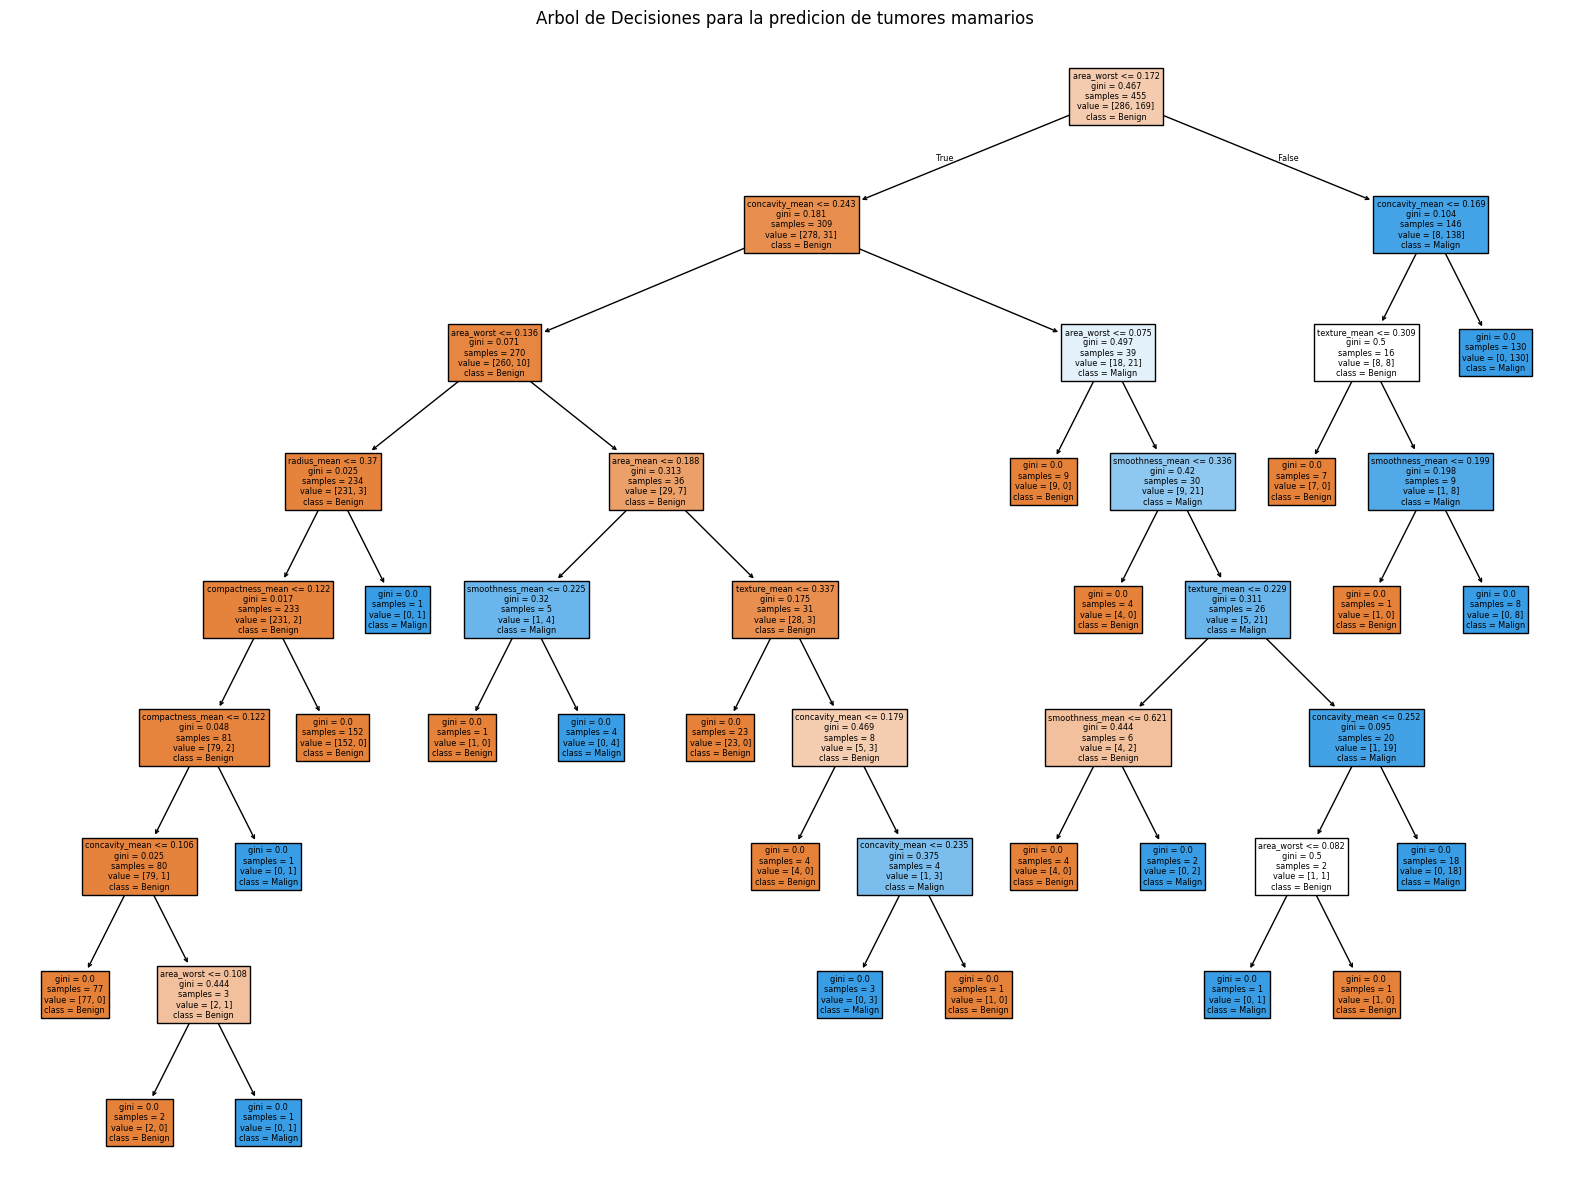

In [ ]:
plt.figure(figsize=(20,15))
tree.plot_tree(arbol, filled=True, feature_names=head_norm, class_names=["Benign", "Malign"])
plt.title("Arbol de Decisiones para la predicion de tumores mamarios")
plt.savefig("Prediccion_tumores_mamarios.png", dpi =300)
plt.show()

In [ ]:
_

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN
5,843786,M,12.45,15.70,82.57,477.1,0.12780,0.17000,0.15780,0.08089,...,23.75,103.40,741.6,0.1791,0.5249,0.5355,0.1741,0.3985,0.12440,NaN
6,844359,M,18.25,19.98,119.60,1040.0,0.09463,0.10900,0.11270,0.07400,...,27.66,153.20,1606.0,0.1442,0.2576,0.3784,0.1932,0.3063,0.08368,NaN
7,84458202,M,13.71,20.83,90.20,577.9,0.11890,0.16450,0.09366,0.05985,...,28.14,110.60,897.0,0.1654,0.3682,0.2678,0.1556,0.3196,0.11510,NaN
8,844981,M,13.00,21.82,87.50,519.8,0.12730,0.19320,0.18590,0.09353,...,30.73,106.20,739.3,0.1703,0.5401,0.5390,0.2060,0.4378,0.10720,NaN
9,84501001,M,12.46,24.04,83.97,475.9,0.11860,0.23960,0.22730,0.08543,...,40.68,97.65,711.4,0.1853,1.0580,1.1050,0.2210,0.4366,0.20750,NaN
